In [16]:
# Imports necessary libraries for building the CNN model and visualizing data.

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

### Data pre-processing :

In [17]:
# Defines key hyperparameters used throughout the model.
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [18]:
# Downloads dataset from KaggleHub for eye disease classification.
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gunavenkatdoddi/eye-diseases-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/eye-diseases-classification


In [21]:
# Lists the contents of the dataset directory to access the directory structure.
!ls -R /kaggle/input/eye-diseases-classification

/kaggle/input/eye-diseases-classification:
dataset

/kaggle/input/eye-diseases-classification/dataset:
cataract  diabetic_retinopathy	glaucoma  normal

/kaggle/input/eye-diseases-classification/dataset/cataract:
_0_4015166.jpg	  2113_left.jpg     _244_5451565.jpg  _390_5561281.jpg
0_left.jpg	  2113_right.jpg    _245_498355.jpg   _391_2115124.jpg
_100_334408.jpg   2114_left.jpg     _245_5686342.jpg  _391_3026815.jpg
_101_5139882.jpg  2114_right.jpg    _245_789720.jpg   _392_3084035.jpg
_101_709333.jpg   2115_right.jpg    _24_6096407.jpg   _392_7918570.jpg
_102_1024926.jpg  2116_left.jpg     _246_8777337.jpg  _393_746807.jpg
_102_3990401.jpg  2116_right.jpg    _247_7009710.jpg  _394_1321417.jpg
_10_3215668.jpg   2117_left.jpg     _247_9509040.jpg  _394_4972049.jpg
_103_5897328.jpg  2118_right.jpg    _248_3607543.jpg  _395_8303850.jpg
103_left.jpg	  _211_9288352.jpg  _24_8522038.jpg   _396_4783302.jpg
_104_4607170.jpg  2119_right.jpg    _248_8765348.jpg  _396_6097231.jpg
_105_5646774.jpg 

In [22]:
# Loads the dataset from directory, shuffles it, and resizes images.
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/eye-diseases-classification/dataset",
    shuffle=True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 4217 files belonging to 4 classes.


In [23]:
# Extracts and displays the class labels from the dataset.
class_names = dataset.class_names
class_names

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

In [24]:
# Checks how many batches are in the entire dataset.
len(dataset)

132

### Visualization

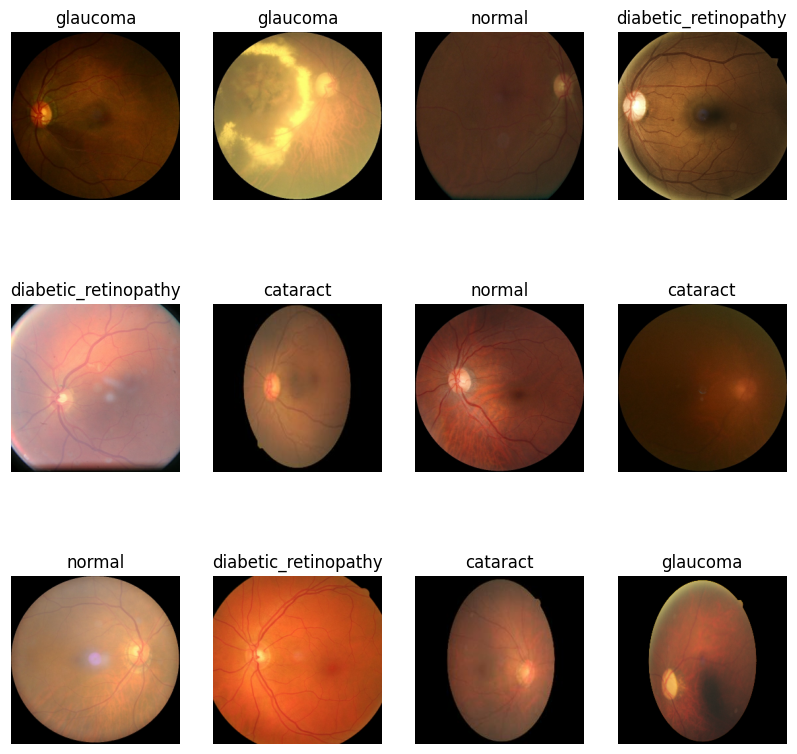

In [25]:
# Displays a sample of 12 images with their class labels
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

### Dataset Split Criteria - <br>
80% ==> training <br>
10% ==> validation <br>
10% ==> testing <br>

In [26]:
# Splits dataset into training, validation, and test sets
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size  = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size  = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

In [27]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [28]:
# Displays length of train datasets
len(train_ds)

105

In [29]:
# Displays length of validation datasets
len(val_ds)

13

In [30]:
# Displays length of test datasets
len(test_ds)

14

In [31]:
# Caches, shuffles, and prefetches datasets to improve performance
trains_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

### Rescaling and resizing

In [32]:
# Resizes and rescales images to normalize pixel values between 0 and 1
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

### Data Augmentation

In [33]:
# Applies data augmentation (flipping, rotation) to improve generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])


### Model Building

In [35]:

# Defines the CNN model architecture using several Conv2D + MaxPool layers followed by Dense layers
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 4
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape), # Updated input_shape
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation ='softmax'),

])

In [36]:
# Compiles the model with Adam optimizer and categorical cross-entropy loss
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [37]:
checkpoint_path = "my_model.keras"

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [38]:
# Trains the model using training data and validates on validation data
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 56s 221ms/step - accuracy: 0.3343 - loss: 1.3259 - val_accuracy: 0.5264 - val_loss: 1.0975
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.5560 - loss: 1.0050 - val_accuracy: 0.5697 - val_loss: 0.9748
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.6464 - loss: 0.8255 - val_accuracy: 0.6683 - val_loss: 0.7943
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7024 - loss: 0.7017 - val_accuracy: 0.7091 - val_loss: 0.6751
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.7426 - loss: 0.6254 - val_accuracy: 0.7260 - val_loss: 0.6490
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.7561 - loss: 0.5974 - val_accuracy: 0.7380 - val_loss: 0.6014
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.7727 - loss: 0.5493 - val_accuracy: 0.7332 - val_loss: 0.6318
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.7907 - loss: 0.5005 -

In [39]:
# Prints model summary showing each layer and parameter count
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,438 (2.10 MB)

 Trainable params: 183,812 (718.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 367,626 (1.40 MB)

### Model Evaluation

In [40]:
# Evaluates the trained model on the test dataset and prints final accuracy/loss
scores = model.evaluate(test_ds)

14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8933 - loss: 0.3221


In [41]:
scores

[0.2909466624259949, 0.9017857313156128]

In [42]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 105}

In [43]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [44]:
history.history['accuracy']

[0.4130629301071167,
 0.5785863399505615,
 0.6641813516616821,
 0.7142857313156128,
 0.7476190328598022,
 0.7584252953529358,
 0.7787056565284729,
 0.7927229404449463,
 0.8004772067070007,
 0.8076349496841431,
 0.8079332113265991,
 0.818371593952179,
 0.8240381479263306,
 0.8407396078109741,
 0.8338801264762878,
 0.8374589681625366,
 0.8416343331336975,
 0.842827320098877,
 0.8467044234275818,
 0.8449404835700989,
 0.855654776096344,
 0.8514763116836548,
 0.8622129559516907,
 0.8613182306289673,
 0.8568452596664429,
 0.8571428656578064,
 0.8574411273002625,
 0.8508928418159485,
 0.8586340546607971,
 0.8640024065971375,
 0.8592305183410645,
 0.8651953339576721,
 0.874404788017273,
 0.8774232268333435,
 0.8705636858940125,
 0.8663883209228516,
 0.8690476417541504,
 0.8708618879318237,
 0.8744407892227173,
 0.882440447807312,
 0.8789144158363342,
 0.87384432554245,
 0.8750372529029846,
 0.8747390508651733,
 0.8797619342803955,
 0.8773809671401978,
 0.8768267035484314,
 0.8818967938423157,

In [45]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

### Accuaracy and Loss Visualization

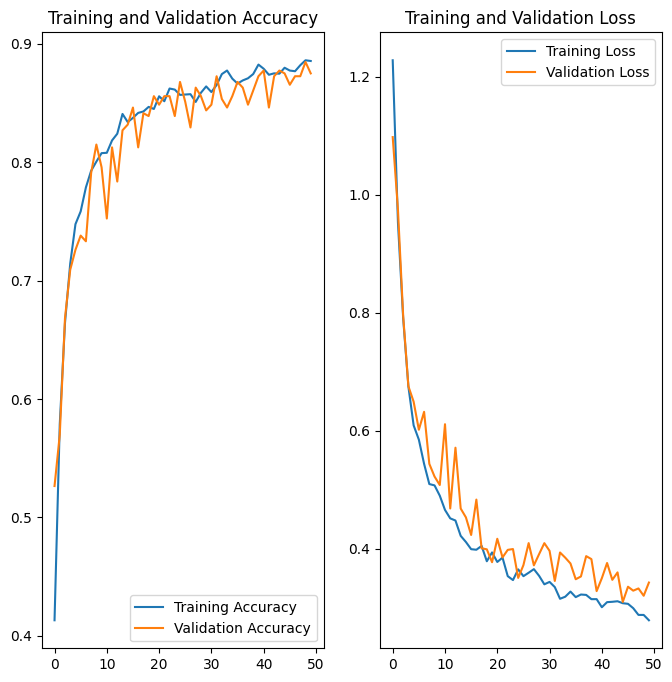

In [46]:
# Plots training vs validation accuracy and loss to visualize model performance
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')


plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#

### Model Prediction

first image to predict
first image's actual label: cataract
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
predicted label:  cataract


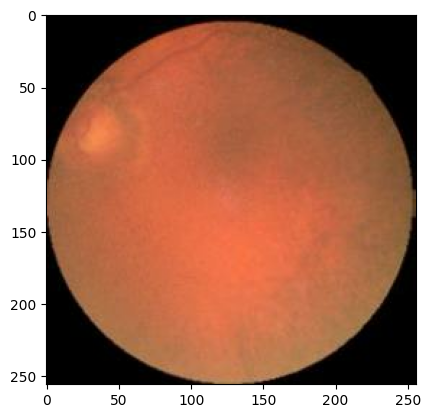

In [47]:
# Makes predictions on a single image from the test dataset and prints actual vs predicted label
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    first_image =images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("first image's actual label:", class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label: ",class_names[np.argmax(batch_prediction[0])])

In [48]:
# Defines a reusable prediction function to classify a single image
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

### Model Prediction with Confidence Scores

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


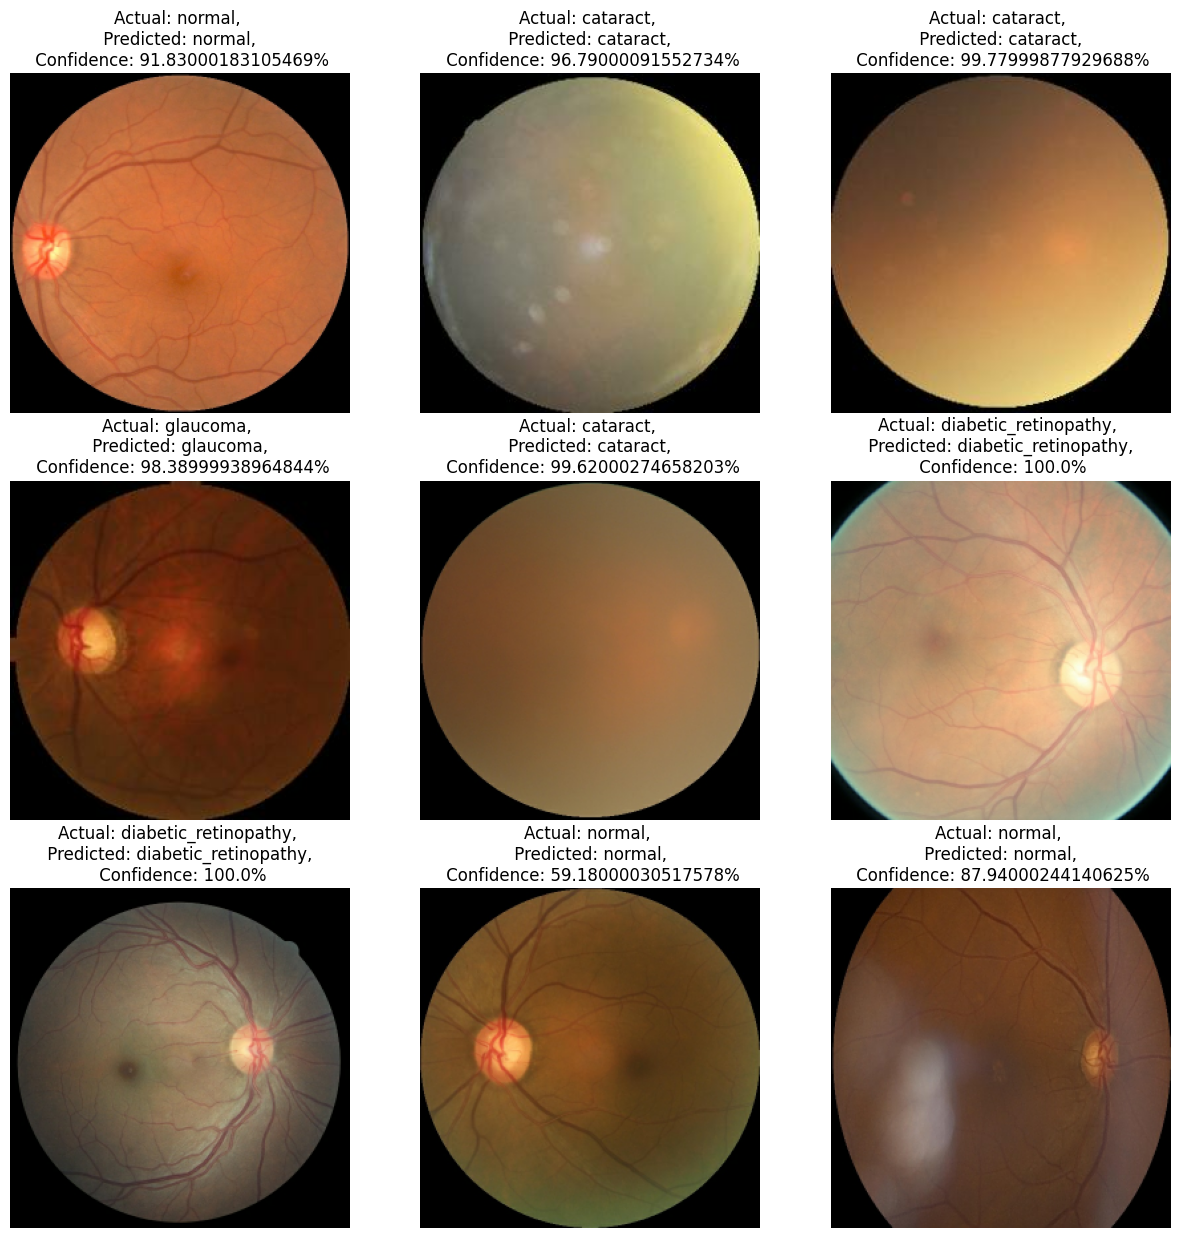

In [49]:
# Visualizes 9 predictions from the test dataset along with confidence and true labels
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}, \n Confidence: {confidence}%")

        plt.axis("off")

### Model Saving and Versioning

In [50]:
# Saves the trained model in .keras format
model.save("my_model.keras")

In [51]:
# Downloads the saved model to your local machine
from google.colab import files
files.download("my_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>